<a href="https://colab.research.google.com/github/elizabethputhumana/QR_Code-Generator/blob/main/ML1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [333]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [334]:
data = pd.read_csv("/content/titanic.csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [335]:
data.shape

(891, 12)

In [336]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [337]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [338]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [339]:
data.isnull().sum()*100 /len(data)

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [340]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [341]:
data.drop(['Cabin','PassengerId'],axis=1,inplace=True)

In [342]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')

In [343]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [344]:
data['Pclass'].unique()

array([3, 1, 2])

In [345]:
data['Survived'].unique()

array([0, 1])

In [346]:
data['Embarked'].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [347]:
data['Sex'].unique()

array(['male', 'female'], dtype=object)

In [348]:
data['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [349]:
data['Pclass'].value_counts()

,count
Pclass,
3,491
1,216
2,184


In [350]:
data['Survived'].value_counts()

,count
Survived,
0,549
1,342


In [351]:
data['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [352]:
data['Embarked'].value_counts()

,count
Embarked,
S,644
C,168
Q,77


In [353]:
data['Age'].value_counts()

,count
Age,
24.00,30
22.00,27
18.00,26
28.00,25
30.00,25
...,...
24.50,1
0.67,1
0.42,1


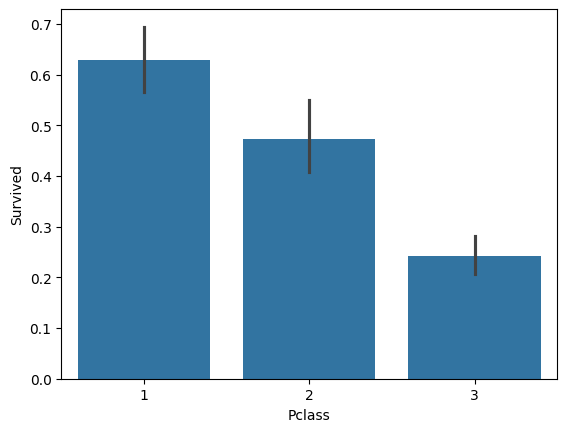

In [354]:
sns.barplot(x='Pclass',y='Survived',data=data)
plt.show()

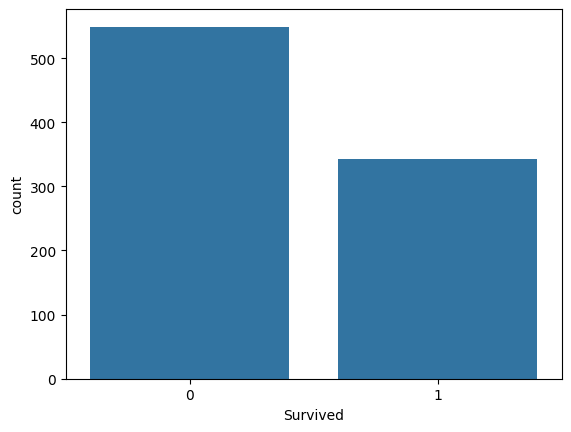

In [355]:
sns.countplot(x='Survived',data=data)
plt.show()

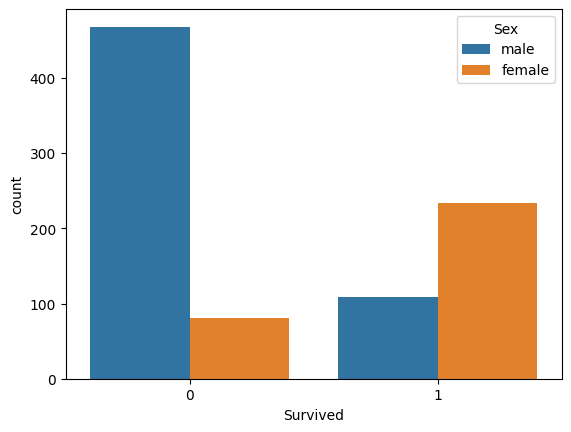

In [356]:
sns.countplot(x='Survived',hue='Sex',data=data)
plt.show()

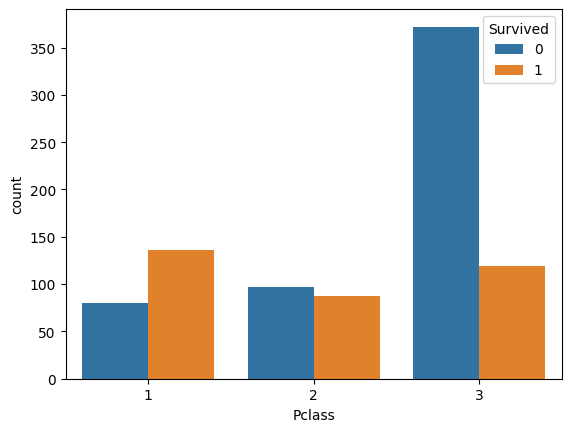

In [357]:
sns.countplot(x='Pclass',hue='Survived',data=data)
plt.show()

In [358]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')

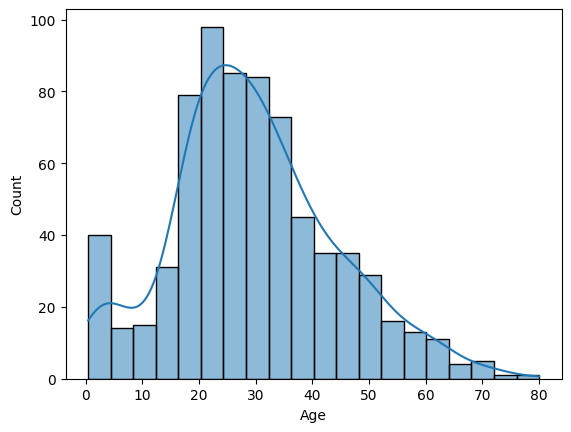

In [359]:
sns.histplot(x='Age',data=data,kde=True)
plt.show()

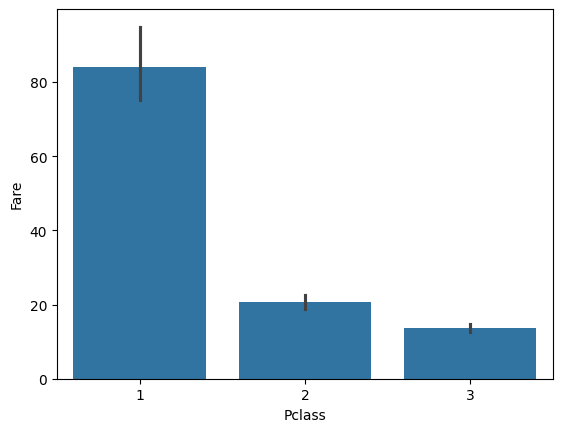

In [360]:
sns.barplot(x='Pclass',y='Fare',data=data)
plt.show()

In [361]:
data['Age_category']=data['Age'].apply(lambda x:'child' if x<18 else 'adult')

In [362]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult


In [363]:
data.tail()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,S,adult
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,S,adult
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,S,adult
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C,adult
890,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,Q,adult


In [364]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,adult
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,adult
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,adult
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,adult


In [365]:
data['Family_count']=data['SibSp']+data['Parch']+1

In [366]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family_count
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,adult,1
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,adult,1
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,adult,4
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,adult,1


In [367]:
data['Fare_group']=pd.qcut(data['Fare'], q=4, labels=['Low','Medium','High','Very high'])

In [368]:
data.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family_count,Fare_group
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult,2,Low
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult,2,Very high
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult,1,Medium
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult,2,Very high
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult,1,Medium


In [369]:
data.Fare_group

,Fare_group
0,Low
1,Very high
2,Medium
3,Very high
4,Medium
...,...
886,Medium
887,High
888,High
889,High


In [370]:
data.Name

,Name
0,"Braund, Mr. Owen Harris"
1,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
2,"Heikkinen, Miss. Laina"
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
4,"Allen, Mr. William Henry"
...,...
886,"Montvila, Rev. Juozas"
887,"Graham, Miss. Margaret Edith"
888,"Johnston, Miss. Catherine Helen ""Carrie"""
889,"Behr, Mr. Karl Howell"


In [371]:
data[['LastName','RemainingName']]=data['Name'].str.split(',',n=1,expand=True)
data[['Name','LastName','RemainingName']].head()

,Name,LastName,RemainingName
0,"Braund, Mr. Owen Harris",Braund,Mr. Owen Harris
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,"Heikkinen, Miss. Laina",Heikkinen,Miss. Laina
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,"Allen, Mr. William Henry",Allen,Mr. William Henry


In [372]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family_count,Fare_group,LastName,RemainingName
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult,2,Low,Braund,Mr. Owen Harris
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult,2,Very high,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult,1,Medium,Heikkinen,Miss. Laina
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult,2,Very high,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult,1,Medium,Allen,Mr. William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,adult,1,Medium,Montvila,Rev. Juozas
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,adult,1,High,Graham,Miss. Margaret Edith
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,S,adult,4,High,Johnston,"Miss. Catherine Helen ""Carrie"""
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,adult,1,High,Behr,Mr. Karl Howell


In [373]:
data.corr(numeric_only=True)

,Survived,Pclass,Age,SibSp,Parch,Fare,Family_count
Survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307,0.016639
Pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500,0.065997
Age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067,-0.301914
SibSp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651,0.890712
Parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225,0.783111
Fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000,0.217138
Family_count,0.016639,0.065997,-0.301914,0.890712,0.783111,0.217138,1.000000


<Axes: >

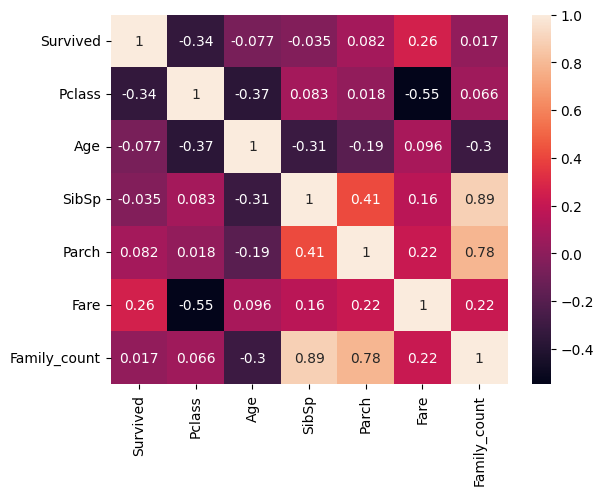

In [374]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

<Axes: >

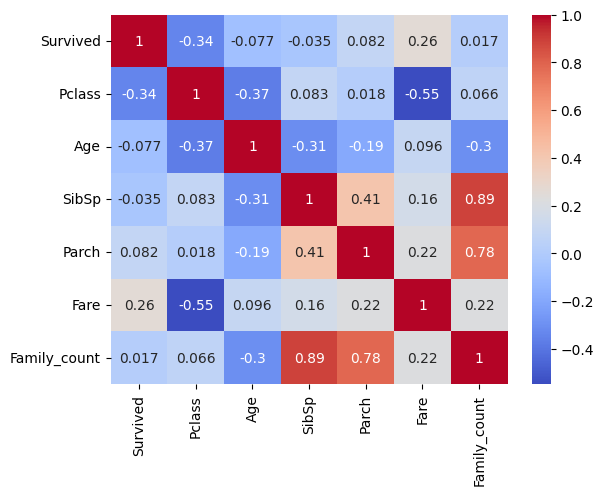

In [375]:
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')

<Axes: >

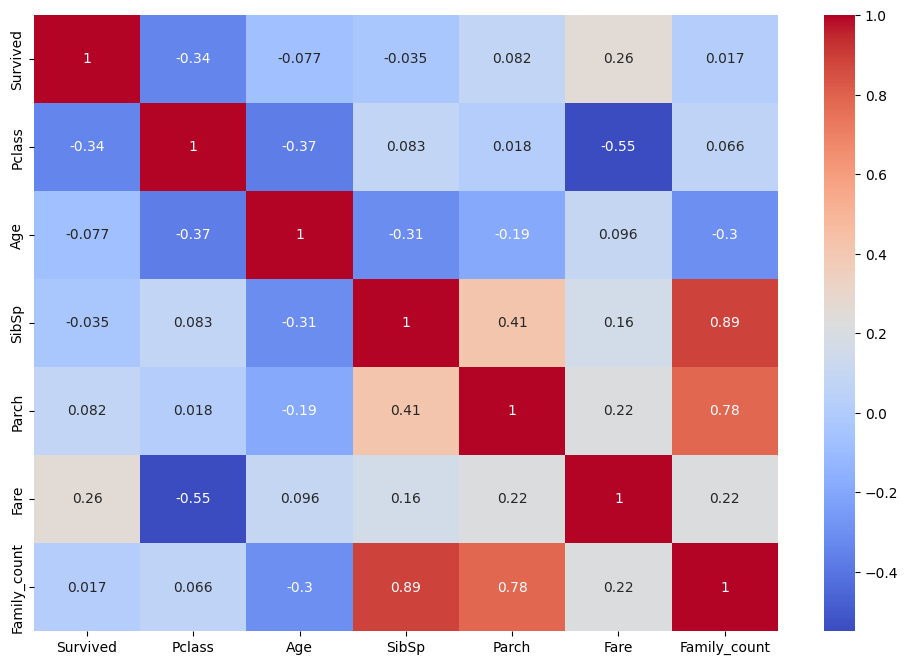

In [376]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [377]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'Age_category', 'Family_count', 'Fare_group',
       'LastName', 'RemainingName'],
      dtype='object')

In [378]:
from sklearn.preprocessing import LabelEncoder

In [379]:
from sklearn.impute import SimpleImputer

In [380]:
data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,2


In [381]:
numeric_columns=['Age']
imputer=SimpleImputer(strategy='median')
data[numeric_columns]=imputer.fit_transform(data[numeric_columns])

In [382]:
data

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family_count,Fare_group,LastName,RemainingName
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,adult,2,Low,Braund,Mr. Owen Harris
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult,2,Very high,Cumings,Mrs. John Bradley (Florence Briggs Thayer)
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,adult,1,Medium,Heikkinen,Miss. Laina
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,adult,2,Very high,Futrelle,Mrs. Jacques Heath (Lily May Peel)
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,adult,1,Medium,Allen,Mr. William Henry
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S,adult,1,Medium,Montvila,Rev. Juozas
887,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S,adult,1,High,Graham,Miss. Margaret Edith
888,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,28.0,1,2,W./C. 6607,23.4500,S,adult,4,High,Johnston,"Miss. Catherine Helen ""Carrie"""
889,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C,adult,1,High,Behr,Mr. Karl Howell


In [383]:
data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,2


In [384]:
cat_col=['Embarked']
cat_imputer=SimpleImputer(strategy='most_frequent')
data[cat_col]=cat_imputer.fit_transform(data[cat_col])

In [385]:
data.isna().sum()

,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0
Embarked,0


In [386]:
data.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'Age_category', 'Family_count', 'Fare_group',
       'LastName', 'RemainingName'],
      dtype='object')

In [387]:
selected_columns=['Survived', 'Pclass', 'Sex', 'Age','SibSp', 'Parch', 'Ticket',
       'Fare']

In [388]:
from sklearn.preprocessing import LabelEncoder
ls=LabelEncoder()
# Include both 'object' and 'category' dtypes for encoding
cal_cols=data.select_dtypes(include=['object', 'category']).columns
for col in cal_cols:
    data[col]=ls.fit_transform(data[col])
data.head(2)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Age_category,Family_count,Fare_group,LastName,RemainingName
0,0,3,108,1,22.0,1,0,523,7.2500,2,0,2,1,73,537
1,1,1,190,0,38.0,1,0,596,71.2833,0,0,2,3,136,738


In [389]:
selected_features = ['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']
X = data[selected_features]
Y = data['Survived']

In [390]:
X.columns

Index(['Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')

In [391]:
Y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,0
889,1


In [392]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [393]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [394]:
prediction=model.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,prediction)

0.7821229050279329

In [395]:
X_test.columns
passenger=[[3,1,29,1,0,501,7,23,2]]
single_passenger_prediction=model.predict(passenger)
if single_passenger_prediction[0]==1:
  print("Passenger survived")
else:
  print("Passenger did not Survive")

Passenger did not Survive


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [399]:
from sklearn.metrics import classification_report,confusion_matrix
prediction = model.predict(X_test)
print(classification_report(Y_test,prediction))
cm = confusion_matrix(Y_test,prediction)
cm

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



array([[89, 16],
       [23, 51]])

In [400]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(Y_test,prediction))
print(classification_report(Y_test,prediction))

[[89 16]
 [23 51]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       105
           1       0.76      0.69      0.72        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



<Axes: >

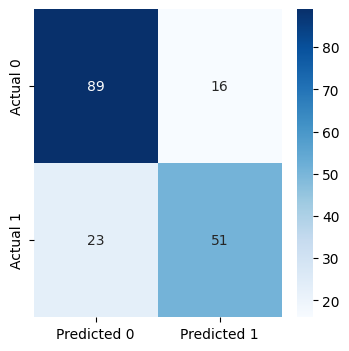

In [401]:
plt.figure(figsize=(4,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Predicted 0','Predicted 1'],yticklabels=['Actual 0','Actual 1'])